# Análisis de tráfico y actividad — Joomla · Nginx · PostgreSQL

**Parcial 2 práctico · Comunicaciones · Ingeniería Mecatrónica**

Este cuaderno se ejecuta **dentro del contenedor `jupyter`**, que está conectado a `frontend_net`
(para hablar con Nginx) y a `backend_net` (para consultar PostgreSQL en `database:5432`).
Las credenciales llegan como variables de entorno desde `.env`, así que no hace falta configurar nada:
basta con **Run → Run All Cells**.

| # | Sección | Fuente de datos |
|---|---------|-----------------|
| 0 | Configuración y conexión | `psycopg2` + `SQLAlchemy` |
| 1 | Contexto de red del contenedor (capas 2 y 3) | `/etc/resolv.conf`, DNS de Docker, tabla ARP |
| 2 | Generación de tráfico de demostración | peticiones HTTP a `http://nginx/` |
| 3 | Tráfico HTTP del proxy | `monitoring.nginx_access` (log de Nginx) |
| 4 | Log de Joomla (Apache) | `monitoring.joomla_access` |
| 5 | Actividad interna de PostgreSQL | `pg_stat_user_tables`, `pg_stat_activity` |
| 6 | Resumen | — |

> Los logs de Nginx y de Apache se escriben en CSV en volúmenes Docker compartidos y PostgreSQL los
> expone como tablas con la extensión `file_fdw` (ver `database/init/01-monitoring.sql`).
> Por eso **Grafana y este cuaderno ven exactamente los mismos datos** con SQL.

## 0. Configuración y conexión a PostgreSQL

In [1]:
import os
import socket
import time
import urllib.request
import urllib.error
from decimal import Decimal

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sqlalchemy import create_engine, text

# --- Credenciales (inyectadas por docker-compose desde .env) ---
PG = {
    "host": os.environ.get("POSTGRES_HOST", "database"),
    "port": os.environ.get("POSTGRES_PORT", "5432"),
    "db":   os.environ.get("POSTGRES_DB", "joomladb"),
    "user": os.environ.get("POSTGRES_USER", "joomla_user"),
    "pass": os.environ.get("POSTGRES_PASSWORD", "joomla_pass_123"),
}
engine = create_engine(
    f"postgresql+psycopg2://{PG['user']}:{PG['pass']}@{PG['host']}:{PG['port']}/{PG['db']}",
    connect_args={"application_name": "jupyter"},   # así se identifica en pg_stat_activity
    pool_pre_ping=True,
)


def q(sql, **params):
    """Ejecuta una consulta y devuelve un DataFrame (vacío si falla, para no romper el cuaderno)."""
    try:
        with engine.connect() as conn:
            res = conn.execute(text(sql), params)
            df = pd.DataFrame(res.fetchall(), columns=list(res.keys()))
        # Las columnas NUMERIC llegan como decimal.Decimal: se pasan a float para operar/graficar
        for col in df.columns:
            if df[col].map(lambda v: isinstance(v, Decimal)).any():
                df[col] = df[col].astype(float)
        return df
    except Exception as exc:
        print(f"⚠️  Error en la consulta: {exc.__class__.__name__}: {str(exc).splitlines()[0]}")
        return pd.DataFrame()


# --- Estilo común de las gráficas (colores iguales a los de Grafana) ---
COLORES_CLASE = {"1xx": "#8F3BB8", "2xx": "#56A64B", "3xx": "#3274D9", "4xx": "#FF9830", "5xx": "#E02F44"}
COLORES_SERVICIO = {"joomla": "#5794F2", "jupyter": "#FF9830", "grafana": "#B877D9"}
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#e5e7eb", "grid.linewidth": 0.8, "axes.titleweight": "bold",
    "axes.titlesize": 11, "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "legend.frameon": False,
})
pd.set_option("display.max_colwidth", 80)

info = q("SELECT version() AS version, inet_server_addr() AS ip_servidor, "
         "inet_client_addr() AS ip_cliente, current_database() AS base")
if not info.empty:
    r = info.iloc[0]
    print("✅ Conectado a PostgreSQL")
    print(f"   Servidor : {PG['host']} ({r.ip_servidor}) puerto TCP {PG['port']}")
    print(f"   Cliente  : {r.ip_cliente}  (esta IP es la del contenedor jupyter en backend_net)")
    print(f"   Base     : {r.base}")
    print(f"   Versión  : {r.version.split(',')[0]}")

✅ Conectado a PostgreSQL
   Servidor : database (172.20.0.2) puerto TCP 5432
   Cliente  : 172.20.0.3  (esta IP es la del contenedor jupyter en backend_net)
   Base     : joomladb
   Versión  : PostgreSQL 16.15 on x86_64-pc-linux-musl


## 1. Contexto de red del contenedor (capas 2 y 3)

Antes de analizar datos, se verifica desde dentro del contenedor lo que describe el `INFORME.md`:

* **DNS embebido de Docker** — `resolv.conf` apunta a `127.0.0.11`, que resuelve los nombres de servicio.
* **Segmentación** — `jupyter` resuelve `database` (comparten `backend_net`) y `nginx` (comparten `frontend_net`).
* **Capa 2** — la tabla ARP del kernel muestra las direcciones MAC aprendidas en cada puente (`eth0`, `eth1`).

In [2]:
with open("/etc/resolv.conf") as fh:
    dns = [line.split()[1] for line in fh if line.startswith("nameserver")]
print("Servidor DNS configurado:", ", ".join(dns))

filas = []
for servicio in ["nginx", "joomla", "grafana", "database", "jupyter"]:
    try:
        ips = sorted({ai[4][0] for ai in socket.getaddrinfo(servicio, None, socket.AF_INET)})
        filas.append({"servicio": servicio, "IP(s) resueltas": ", ".join(ips)})
    except socket.gaierror as exc:
        filas.append({"servicio": servicio, "IP(s) resueltas": f"no resuelve ({exc.strerror})"})
display(pd.DataFrame(filas).set_index("servicio"))

with open("/proc/net/arp") as fh:
    lineas = fh.read().splitlines()[1:]
arp = pd.DataFrame([l.split() for l in lineas],
                   columns=["IP", "HW type", "Flags", "MAC", "Mask", "Interfaz"])
print("Tabla ARP del contenedor (vecinos de capa 2 en los bridges de Docker):")
display(arp[["IP", "MAC", "Interfaz"]] if not arp.empty else "La tabla ARP está vacía todavía.")

Servidor DNS configurado: 127.0.0.11


,IP(s) resueltas
servicio,
nginx,172.19.0.5
joomla,172.19.0.2
grafana,172.19.0.3
database,172.20.0.2
jupyter,172.19.0.4


Tabla ARP del contenedor (vecinos de capa 2 en los bridges de Docker):


,IP,MAC,Interfaz
0,172.19.0.5,9e:11:b6:32:7e:fb,eth1
1,172.20.0.2,8a:90:ac:ad:8a:26,eth0


## 2. Generación de tráfico de demostración

Para que las gráficas tengan datos incluso en un despliegue recién hecho, esta celda envía unas
peticiones HTTP **a través del proxy** (`http://nginx/…`, por `frontend_net`). Incluye rutas
inexistentes a propósito para producir códigos 404. Pon `GENERAR_TRAFICO = False` para omitirla.

In [3]:
GENERAR_TRAFICO = True
RUTAS = ["/", "/index.php", "/index.php/component/users/login", "/index.php?option=com_content",
         "/administrator/", "/no-existe", "/wp-login.php", "/jupyter/api/status"]
RONDAS = 8

if GENERAR_TRAFICO:
    conteo = {}
    t0 = time.time()
    for _ in range(RONDAS):
        for ruta in RUTAS:
            req = urllib.request.Request(f"http://nginx{ruta}",
                                         headers={"User-Agent": "python-urllib (Jupyter demo)"})
            try:
                with urllib.request.urlopen(req, timeout=10) as resp:
                    codigo = resp.status
            except urllib.error.HTTPError as exc:
                codigo = exc.code
            except Exception:
                codigo = "error"
            conteo[codigo] = conteo.get(codigo, 0) + 1
    print(f"Enviadas {RONDAS * len(RUTAS)} peticiones en {time.time() - t0:.1f} s → códigos: {conteo}")
    time.sleep(1)   # deja que Nginx/Apache escriban las últimas líneas del log

Enviadas 64 peticiones en 4.1 s → códigos: {200: 40, 404: 16, 403: 8}


## 3. Tráfico HTTP registrado por Nginx

Cada línea del log de acceso del proxy es una fila de `monitoring.nginx_access`
(IP, servicio de destino, método, URI, código, bytes y tiempos de respuesta).

In [4]:
nginx = q("""
    SELECT ts, ip, servicio, metodo, ruta, status, clase, bytes,
           request_time * 1000 AS latencia_ms, cliente
    FROM monitoring.nginx_access
    WHERE ts > now() - interval '24 hours'
""")

if nginx.empty:
    print("Todavía no hay peticiones registradas: navega por http://localhost/ y vuelve a ejecutar.")
else:
    nginx["ts"] = pd.to_datetime(nginx["ts"], utc=True).dt.tz_convert("America/Bogota")
    resumen = pd.Series({
        "Peticiones (24 h)": len(nginx),
        "IPs distintas": nginx["ip"].nunique(),
        "Tasa de error 4xx/5xx": f"{(nginx['status'] >= 400).mean():.1%}",
        "Latencia p50": f"{nginx['latencia_ms'].median():.0f} ms",
        "Latencia p95": f"{nginx['latencia_ms'].quantile(0.95):.0f} ms",
        "Datos servidos": f"{nginx['bytes'].sum() / 1024 / 1024:.2f} MiB",
    }, name="valor")
    display(resumen.to_frame())
    display(nginx.groupby("servicio").agg(peticiones=("ts", "size"),
                                           latencia_media_ms=("latencia_ms", "mean"))
                 .round(1).sort_values("peticiones", ascending=False))

,valor
Peticiones (24 h),150
IPs distintas,2
Tasa de error 4xx/5xx,26.0%
Latencia p50,56 ms
Latencia p95,83 ms
Datos servidos,0.81 MiB


,peticiones,latencia_media_ms
servicio,,
joomla,110,65.2
grafana,29,17.8
jupyter,11,315.9


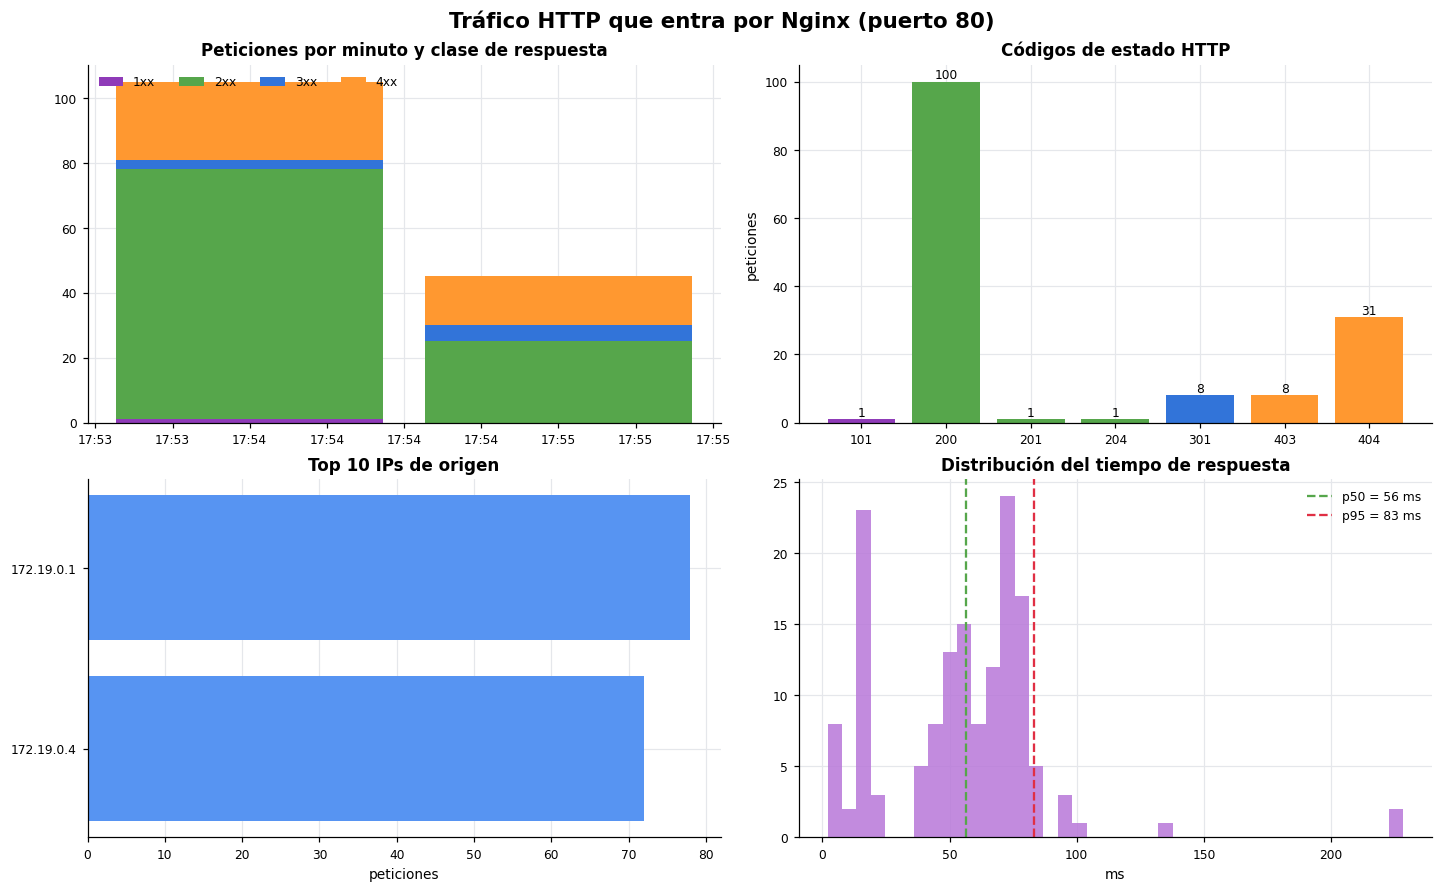

In [5]:
if not nginx.empty:
    fig, axs = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
    fig.suptitle("Tráfico HTTP que entra por Nginx (puerto 80)", fontsize=14, fontweight="bold")

    # (a) Peticiones por minuto, apiladas por clase de estado
    por_min = (nginx.set_index("ts").groupby("clase").resample("1min").size()
                    .unstack(0, fill_value=0).sort_index())
    ax = axs[0, 0]
    base = None
    for clase in sorted(por_min.columns):
        ax.bar(por_min.index, por_min[clase], width=0.0006, bottom=base,
               color=COLORES_CLASE.get(clase, "grey"), label=clase)
        base = por_min[clase] if base is None else base + por_min[clase]
    ax.set_title("Peticiones por minuto y clase de respuesta")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.legend(ncols=4, loc="upper left")

    # (b) Códigos de estado exactos
    ax = axs[0, 1]
    codigos = nginx["status"].value_counts().sort_index()
    ax.bar(codigos.index.astype(str), codigos.values,
           color=[COLORES_CLASE.get(f"{c // 100}xx", "grey") for c in codigos.index])
    for i, v in enumerate(codigos.values):
        ax.text(i, v, f"{v}", ha="center", va="bottom", fontsize=8)
    ax.set_title("Códigos de estado HTTP")
    ax.set_ylabel("peticiones")

    # (c) IPs de origen más frecuentes
    ax = axs[1, 0]
    top_ips = nginx["ip"].value_counts().head(10).sort_values()
    ax.barh(top_ips.index, top_ips.values, color="#5794F2")
    ax.set_title("Top 10 IPs de origen")
    ax.set_xlabel("peticiones")

    # (d) Distribución de latencias con p50 y p95
    ax = axs[1, 1]
    lat = nginx["latencia_ms"].clip(upper=nginx["latencia_ms"].quantile(0.99))
    ax.hist(lat, bins=40, color="#B877D9", alpha=0.85)
    for p, color in [(0.5, "#56A64B"), (0.95, "#E02F44")]:
        v = nginx["latencia_ms"].quantile(p)
        ax.axvline(v, color=color, ls="--", lw=1.5, label=f"p{int(p * 100)} = {v:.0f} ms")
    ax.set_title("Distribución del tiempo de respuesta")
    ax.set_xlabel("ms")
    ax.legend()
    plt.show()

In [6]:
if not nginx.empty:
    rutas = (nginx[nginx["servicio"] == "joomla"]
             .groupby("ruta")
             .agg(peticiones=("ts", "size"),
                  errores=("status", lambda s: int((s >= 400).sum())),
                  latencia_media_ms=("latencia_ms", "mean"),
                  ultima=("ts", "max"))
             .sort_values("peticiones", ascending=False).head(12))
    display(rutas.style
            .format({"latencia_media_ms": "{:.1f}", "ultima": lambda t: t.strftime("%H:%M:%S")})
            .bar(subset=["peticiones"], color="#9ec5fe")
            .map(lambda v: "color: #E02F44; font-weight: bold" if v > 0 else "", subset=["errores"])
            .set_caption("Rutas de Joomla más solicitadas"))

,peticiones,errores,latencia_media_ms,ultima
ruta,,,,
/,24,0,78.5,12:55:02
/index.php,24,0,63.3,12:55:02
/no-existe,23,23,52.6,12:55:02
/index.php/component/users/login,23,0,72.3,12:55:02
/administrator/,8,0,61.6,12:55:02
/wp-login.php,8,8,50.6,12:55:02


## 4. Log de Joomla (Apache dentro del contenedor del CMS)

Apache registra cada petición que le llega desde Nginx en `joomla_access.csv`. Gracias a
`mod_remoteip` la columna `ip` es la del cliente real (tomada de `X-Forwarded-For`), mientras que
`ip_proxy` es la IP de Nginx en `frontend_net`: la evidencia de que todo pasa por el proxy.

Pares (cliente real → proxy) observados por Apache:


,,peticiones
ip,ip_proxy,
172.19.0.1,172.19.0.5,46
172.19.0.4,172.19.0.5,64


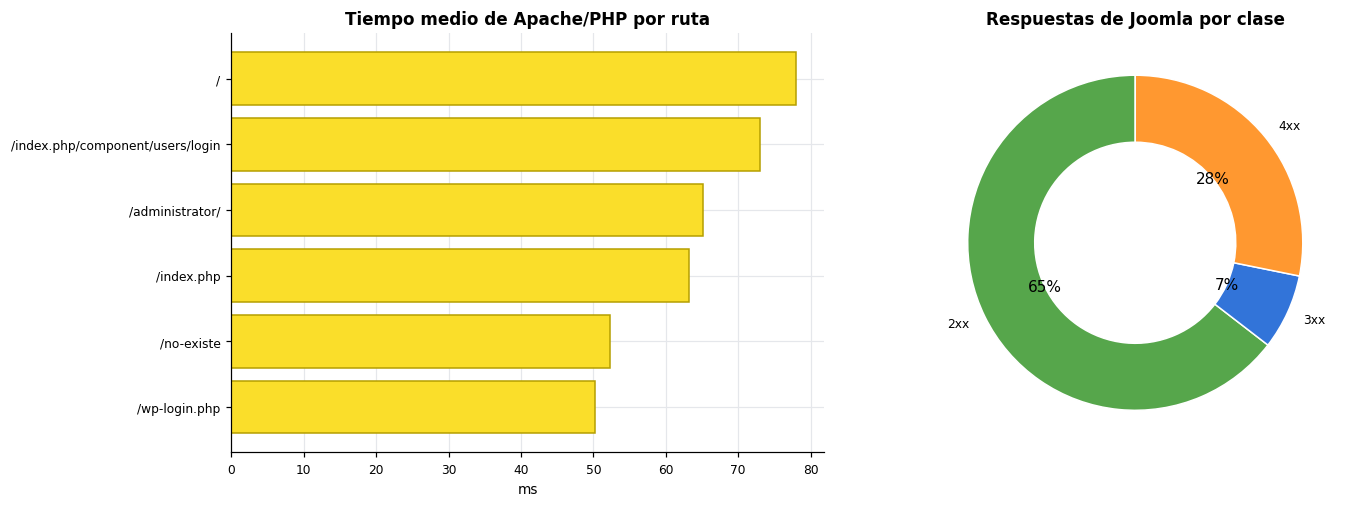

In [7]:
joomla = q("""
    SELECT ts, ip, ip_proxy, metodo, ruta, status, clase, duracion_ms
    FROM monitoring.joomla_access
    WHERE ts > now() - interval '24 hours'
""")

if joomla.empty:
    print("Sin registros de Apache todavía.")
else:
    print("Pares (cliente real → proxy) observados por Apache:")
    display(joomla.groupby(["ip", "ip_proxy"]).size().rename("peticiones").to_frame())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
    por_ruta = (joomla.groupby("ruta")["duracion_ms"].agg(["mean", "count"])
                      .sort_values("count", ascending=False).head(8).sort_values("mean"))
    ax1.barh(por_ruta.index, por_ruta["mean"], color="#FADE2A", edgecolor="#b59f00")
    ax1.set_title("Tiempo medio de Apache/PHP por ruta")
    ax1.set_xlabel("ms")

    clases = joomla["clase"].value_counts().sort_index()
    ax2.pie(clases.values, labels=clases.index, autopct="%1.0f%%", startangle=90,
            colors=[COLORES_CLASE.get(c, "grey") for c in clases.index],
            wedgeprops={"width": 0.4, "edgecolor": "white"})
    ax2.set_title("Respuestas de Joomla por clase")
    plt.show()

## 5. Actividad interna de PostgreSQL

Cada visita a Joomla genera lecturas y escrituras (sesión, menús, extensiones…). Las vistas de
estadísticas de PostgreSQL lo reflejan sin depender del prefijo aleatorio de las tablas del CMS.

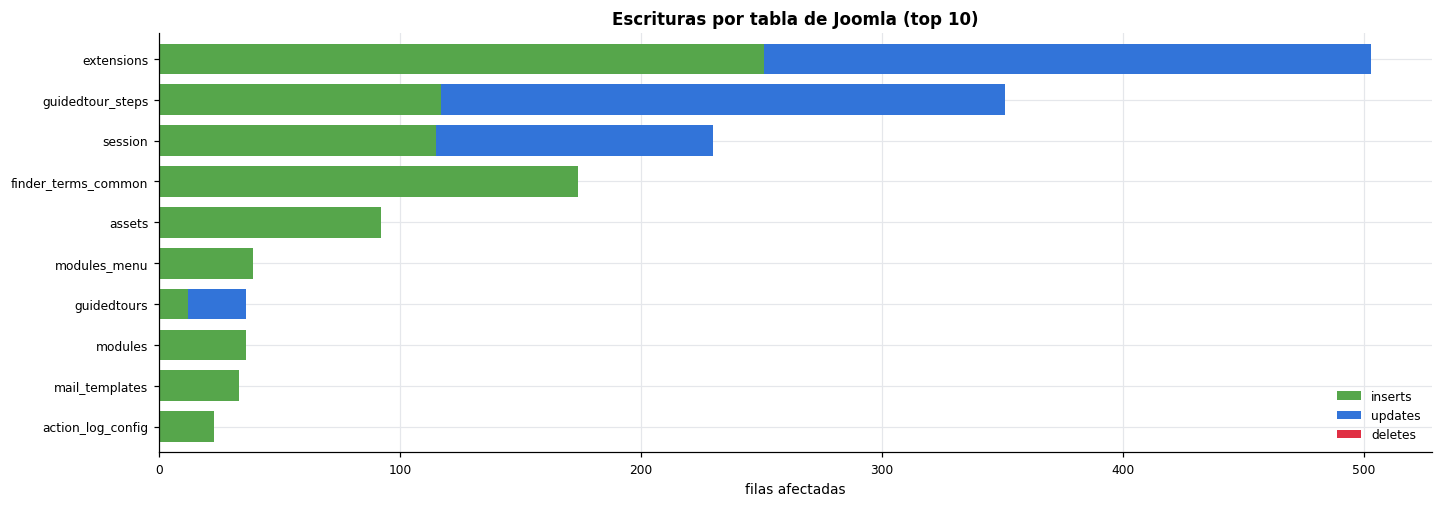

Conexiones abiertas contra la base de datos (IPs de backend_net):


,ip_cliente,aplicacion,estado,conexiones
0,172.20.0.3,jupyter,active,1
1,172.20.0.5,(sin nombre),idle,1


In [8]:
tablas = q("""
    SELECT regexp_replace(relname, '^[a-z0-9]+_', '') AS tabla,
           n_tup_ins AS inserts, n_tup_upd AS updates, n_tup_del AS deletes,
           COALESCE(seq_tup_read, 0) + COALESCE(idx_tup_fetch, 0) AS lecturas
    FROM pg_stat_user_tables WHERE schemaname = 'public'
    ORDER BY n_tup_ins + n_tup_upd + n_tup_del DESC
    LIMIT 10
""")
conexiones = q("""
    SELECT COALESCE(host(client_addr), 'local') AS ip_cliente,
           COALESCE(NULLIF(application_name, ''), '(sin nombre)') AS aplicacion,
           state AS estado, count(*) AS conexiones
    FROM pg_stat_activity WHERE datname = current_database()
    GROUP BY 1, 2, 3 ORDER BY conexiones DESC
""")

if not tablas.empty:
    fig, ax = plt.subplots(figsize=(13, 4.5), constrained_layout=True)
    datos = tablas.set_index("tabla")[["inserts", "updates", "deletes"]].iloc[::-1]
    datos.plot.barh(stacked=True, ax=ax, color=["#56A64B", "#3274D9", "#E02F44"], width=0.75)
    ax.set_title("Escrituras por tabla de Joomla (top 10)")
    ax.set_xlabel("filas afectadas")
    ax.set_ylabel("")
    plt.show()

print("Conexiones abiertas contra la base de datos (IPs de backend_net):")
display(conexiones)

## 6. Resumen

In [9]:
lineas = []
if not nginx.empty:
    lineas.append(f"* Nginx registró **{len(nginx)} peticiones** de **{nginx['ip'].nunique()} IP(s)** en las últimas 24 h; "
                  f"el {(nginx['status'] >= 400).mean():.0%} terminó en error 4xx/5xx.")
    lineas.append(f"* Latencia del proxy: p50 = {nginx['latencia_ms'].median():.0f} ms, "
                  f"p95 = {nginx['latencia_ms'].quantile(0.95):.0f} ms.")
if not joomla.empty:
    lineas.append(f"* Apache (Joomla) procesó **{len(joomla)} peticiones**, todas recibidas desde el proxy "
                  f"`{', '.join(joomla['ip_proxy'].unique())}`.")
if not tablas.empty:
    t = tablas.iloc[0]
    lineas.append(f"* La tabla con más escrituras es **{t.tabla}** "
                  f"({int(t.inserts + t.updates + t.deletes)} filas afectadas).")
if not conexiones.empty:
    lineas.append(f"* PostgreSQL mantiene **{int(conexiones['conexiones'].sum())} conexiones** desde "
                  f"{conexiones['ip_cliente'].nunique()} contenedor(es) de `backend_net`.")

from IPython.display import Markdown
display(Markdown("\n".join(lineas) or "No hay datos todavía."))

* Nginx registró **150 peticiones** de **2 IP(s)** en las últimas 24 h; el 26% terminó en error 4xx/5xx.
* Latencia del proxy: p50 = 56 ms, p95 = 83 ms.
* Apache (Joomla) procesó **110 peticiones**, todas recibidas desde el proxy `172.19.0.5`.
* La tabla con más escrituras es **extensions** (503 filas afectadas).
* PostgreSQL mantiene **2 conexiones** desde 2 contenedor(es) de `backend_net`.